In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
plt.rc('font', family = 'Malgun Gothic')

In [3]:
df = pd.read_csv(r"C:\Users\kicki\제로베이스파이썬\Excel_Practice\서울특별시_공공자전거_대여이력.csv", encoding = 'euc-kr')

In [4]:
df.head()

,자전거번호,대여일시,대여 대여소명,반납일시,반납대여소명,이용거리(M),생년,성별,이용자종류,자전거구분
0,SPB-38138,2024-12-01 00:00:13,선유도역 3번출구 앞,2024-12-01 00:02:41,양평동성원아파트,625.10,1997,M,내국인,일반자전거
1,SPB-54015,2024-12-01 00:01:22,마곡수명산파크 209동 건너편,2024-12-01 00:03:31,마곡수명산 1-2단지,0.00,1983,NaN,내국인,일반자전거
2,SPB-59421,2024-12-01 00:00:24,삼성생명 당산사옥 앞,2024-12-01 00:04:11,양평동6차현대아파트 앞,890.00,1991,\N,내국인,일반자전거
3,SPB-32929,2024-12-01 00:00:34,등촌5단지아파트 버스정류장,2024-12-01 00:04:50,강서구청사거리(부민병원),671.61,1994,\N,내국인,일반자전거
4,SPB-39202,2024-12-01 00:01:15,천호역 10번 출구 앞,2024-12-01 00:04:54,송파지역자활센터 뒤,49.16,\N,M,내국인,일반자전거


In [5]:
df['대여일시'] = pd.to_datetime(df['대여일시'])
df['반납일시'] = pd.to_datetime(df['반납일시'])

In [6]:
# 이용시간(초)
df['이용시간(초)'] = (df['반납일시'] - df['대여일시']).dt.seconds

In [7]:
df['이용시간(초)'].head()

0    148
1    129
2    227
3    256
4    219
Name: 이용시간(초), dtype: int32

In [8]:
# 이용거리 (M) 분포확인하기 # Max값인 15942는 대전 ~ 서울 거리
df['이용거리(M)'].describe()
# 의문점이 생겨야한다: 최소값이 0인애들이 있네? Max 값은 저게 맞아? 서울시 대여자전거인데? 오류값 아니야?

count    594023.000000
mean       1894.013409
std        2261.988645
min           0.000000
25%         760.000000
50%        1240.160000
75%        2155.825000
max      159421.410000
Name: 이용거리(M), dtype: float64

In [9]:
# 전처리 1: 이용거리 0 인것은 제외하자 loc통해 >0 추출
df = df.loc[df['이용거리(M)'] > 0]

In [10]:
# 전처리 2: 평균속도가 비정상 추출
df['평균속도(M/S)'] = df['이용거리(M)'] / df['이용시간(초)']
df['평균속도(M/S)'].describe()
# 딱 봐도 Min / Max 값이 말도 안되서 전처리 필요하다

count    573752.000000
mean          2.244747
std           1.389132
min           0.000004
25%           1.708374
50%           2.292818
75%           2.809524
max         332.169780
Name: 평균속도(M/S), dtype: float64

In [11]:
df = df.loc[df['평균속도(M/S)'] < 10] # 10이상은 비현실이라고 판단
df.head(3)

,자전거번호,대여일시,대여 대여소명,반납일시,반납대여소명,이용거리(M),생년,성별,이용자종류,자전거구분,이용시간(초),평균속도(M/S)
0,SPB-38138,2024-12-01 00:00:13,선유도역 3번출구 앞,2024-12-01 00:02:41,양평동성원아파트,625.10,1997,M,내국인,일반자전거,148,4.223649
2,SPB-59421,2024-12-01 00:00:24,삼성생명 당산사옥 앞,2024-12-01 00:04:11,양평동6차현대아파트 앞,890.00,1991,\N,내국인,일반자전거,227,3.920705
3,SPB-32929,2024-12-01 00:00:34,등촌5단지아파트 버스정류장,2024-12-01 00:04:50,강서구청사거리(부민병원),671.61,1994,\N,내국인,일반자전거,256,2.623477


In [12]:
# 전처리 3: 생년 결측제외
df['생년'].describe()
sorted(df['생년'].unique()) # 오류가 보인다

['0000',
 '1900',
 '1901',
 '1902',
 '1903',
 '1904',
 '1905',
 '1906',
 '1907',
 '1908',
 '1910',
 '1918',
 '1920',
 '1923',
 '1926',
 '1927',
 '1931',
 '1932',
 '1933',
 '1934',
 '1935',
 '1936',
 '1937',
 '1938',
 '1939',
 '1940',
 '1941',
 '1942',
 '1943',
 '1944',
 '1945',
 '1946',
 '1947',
 '1948',
 '1949',
 '1950',
 '1951',
 '1952',
 '1953',
 '1954',
 '1955',
 '1956',
 '1957',
 '1958',
 '1959',
 '1960',
 '1961',
 '1962',
 '1963',
 '1964',
 '1965',
 '1966',
 '1967',
 '1968',
 '1969',
 '1970',
 '1971',
 '1972',
 '1973',
 '1974',
 '1975',
 '1976',
 '1977',
 '1978',
 '1979',
 '1980',
 '1981',
 '1982',
 '1983',
 '1984',
 '1985',
 '1986',
 '1987',
 '1988',
 '1989',
 '1990',
 '1991',
 '1992',
 '1993',
 '1994',
 '1995',
 '1996',
 '1997',
 '1998',
 '1999',
 '2000',
 '2001',
 '2002',
 '2003',
 '2004',
 '2005',
 '2006',
 '2007',
 '2008',
 '2009',
 '2010',
 '2011',
 '2012',
 '2013',
 '2014',
 '2015',
 '2016',
 '2017',
 '2019',
 '2020',
 '2021',
 '2047',
 '2049',
 '2051',
 '2053',
 '2059',
 

In [13]:
def valid_birth(birth):
    output = False # technique = output = False를 Default로 만든다
    if birth.isdigit(): # 숫자로 구성된 문자인지 체크 > 이걸만족시켜야만 True 값이 나온다
        if 1960 <= int(birth) <= 2025:
            output = True
    return output

In [14]:
df = df.loc[df['생년'].apply(valid_birth)]

In [15]:
# 전처리 3: 성별
df['성별'].unique()

array(['M', '\\N', 'F', nan, 'f', 'm'], dtype=object)

In [16]:
df['성별'] = df['성별'].str.upper() # 대문자로 바꿔주고
df = df.loc[df['성별'].isin(['F', 'M'])] # F & M 빼고 다 바꿔준다

In [17]:
df['성별'].unique()

array(['M', 'F'], dtype=object)

In [18]:
# 전처리 : 이용자 종류
df['이용자종류'].unique() # 처음에는 내국인과 비회원이라고 구분되는지 알았지만,
df['이용자종류'].value_counts() # Count로 확인해보니 비회원 1은 오류로 지정 > Drop

이용자종류
내국인    343141
비회원         1
Name: count, dtype: int64

In [19]:
df = df.loc[df['이용자종류'] != '비회원'].drop('이용자종류', axis = 1)
# or df = df.loc[df['이용자종류'] == '내국인']

In [20]:
# 전치리 : 자전거
df['자전거구분'].unique()

array(['일반자전거', '\\N', '새싹자전거'], dtype=object)

In [21]:
df = df.loc[df['자전거구분'] != '\\N']

In [22]:
# 대여소 처리 > '\\N' 제외해준다
sorted(df['대여 대여소명'].unique())

['(시립)고덕평생학습관',
 '(재)FITI시험연구원',
 '3호선 매봉역 3번출구앞',
 '419민주묘지 입구사거리',
 '419민주묘지역',
 '419민주묘지역 1번출구',
 '419탑 앞',
 '500번,507번 버스 종점 앞',
 '63스퀘어',
 '7번가피자 서교망원점',
 '7호선 이수역7번출구',
 '9호선종합운동장역 9번출구',
 'CBS방송국 앞',
 'CJ 드림시티',
 'CJ오쇼핑앞',
 'CJ제일제당 앞',
 'DDP 패션몰',
 'DMC래미안e편한세상203동옆',
 'DMC빌 앞',
 'DMC산학협력연구센터 앞',
 'DMC엘가아파트 앞',
 'DMC역 2번출구 옆',
 'DMC역 5번 출구(수색역 방향)',
 'DMC역 9번출구 앞',
 'DMC역7번출구',
 'DMC첨단산업센터',
 'DMC파크뷰자이1단지 110동 앞',
 'DMC파크뷰자이아파트 302동 앞',
 'DMC홍보관',
 'ESA아파트 상가 앞',
 'FITI시험연구원 앞',
 'HID 유족동지회 앞',
 'HW컨벤션센터 앞',
 'H비즈니스파크',
 'H타워 앞',
 'IBK기업은행 석수역 지점 앞',
 'JK장평타워',
 'JTBC 앞',
 'JW타워',
 'K+ 타워 앞',
 'KAIST 경영대학 앞',
 'KBS 스포츠월드',
 'KBS 앞',
 'KBS 연구동 건너편',
 'KB국민은행 염창역 지점 앞',
 'KC 대학교',
 'KCC용산월츠타워',
 'KEB 하나금융그룹 명동사옥 옆',
 'KEB은행 고대점',
 'KG타워 앞',
 'KRX한국거래소(1)',
 'KT 서초지사 앞',
 'KT 전화국 버스정류장 옆',
 'KT&G 관악지점',
 'KT&G강동지사',
 'KT관악지점',
 'KT선릉타워',
 'KT앞',
 'KT플라자 영등포점',
 'KT혜화지사 앞',
 'LG CNS앞',
 'LG 사이언스파크',
 'LG사이언스파크 E10동',
 'LG사이언스파크 E14동',
 'LG사이언스파크 E2동',
 'LG사이언스파크 E7동',
 'LG사이언스파크 W4동

In [23]:
df = df.loc[df['대여 대여소명'] !='\\N']
df = df.loc[df['반납대여소명'] !='\\N']

In [26]:
df.head() # 전처리완료

,자전거번호,대여일시,대여 대여소명,반납일시,반납대여소명,이용거리(M),생년,성별,자전거구분,이용시간(초),평균속도(M/S)
0,SPB-38138,2024-12-01 00:00:13,선유도역 3번출구 앞,2024-12-01 00:02:41,양평동성원아파트,625.10,1997,M,일반자전거,148,4.223649
6,SPB-50712,2024-12-01 00:01:27,신트리공원 입구,2024-12-01 00:05:02,신정1동 주민센터 앞,547.61,1998,M,일반자전거,215,2.547023
8,SPB-41311,2024-12-01 00:01:31,센트럴파크타워 앞,2024-12-01 00:05:13,용산 파크타워 앞,589.79,1969,M,일반자전거,222,2.656712
9,SPB-52417,2024-12-01 00:01:40,천왕이펜하우스3단지 앞,2024-12-01 00:05:27,천왕역 1번 출입구 앞,520.86,1964,M,일반자전거,227,2.294537
10,SPB-47696,2024-12-01 00:00:50,양천향교역 7번출구앞,2024-12-01 00:05:29,마곡금호어울림아파트,810.00,2001,M,일반자전거,279,2.903226


<Axes: xlabel='생년'>

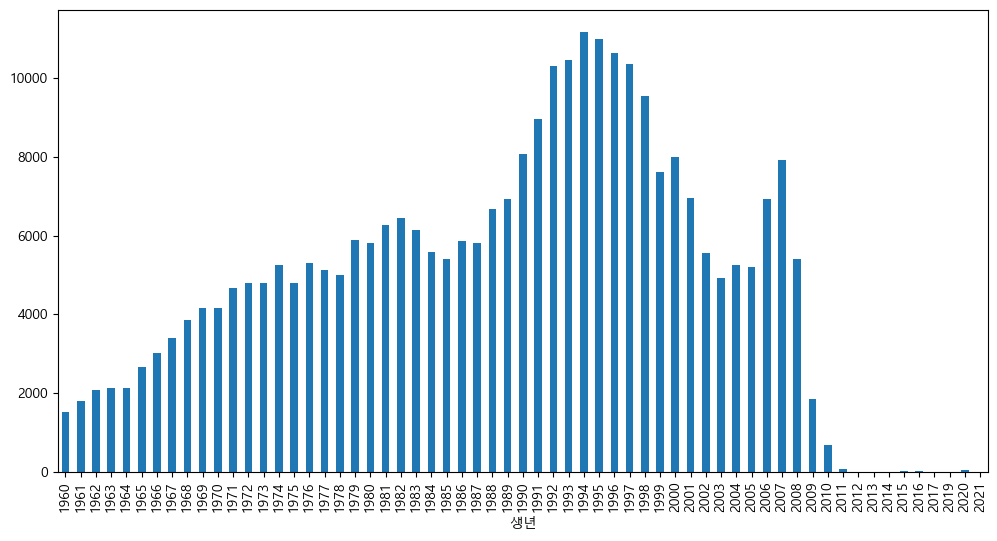

In [37]:
df['생년'].value_counts().sort_index().plot(kind = 'bar', rot = 90, figsize = (12, 6)) # rot = 90 >> Rotation 90%
# df['생년'].value_counts().plot(kind = 'bar', rot = 90, figsize = (12, 6))만 하면 생년에 상관없이 값이 큰 > 작은순서대로

In [39]:
df['성별'].value_counts() # 남성이 여성보다 많이 탄다

성별
M    193956
F    100700
Name: count, dtype: int64

In [40]:
df[['생년', '성별']].value_counts().reset_index() # 생년과 성별 2개를 묶어서 Table 형태로 숫자보여줌

,생년,성별,count
0,1995,M,6853
1,1994,M,6831
2,1992,M,6669
3,1993,M,6599
4,2007,M,6331
...,...,...,...
114,2013,F,1
115,2014,F,1
116,2012,F,1
117,2012,M,1


In [43]:
# 한단계 더 업그레이드하려면 Pivot
df[['생년', '성별']].value_counts().reset_index().pivot(index = '생년', columns = '성별', values = 'count')

성별,F,M
생년,,
1960,343.0,1184.0
1961,458.0,1351.0
1962,425.0,1657.0
1963,551.0,1571.0
1964,619.0,1520.0
...,...,...
2016,23.0,NaN
2017,3.0,NaN
2019,1.0,10.0


<Axes: xlabel='생년'>

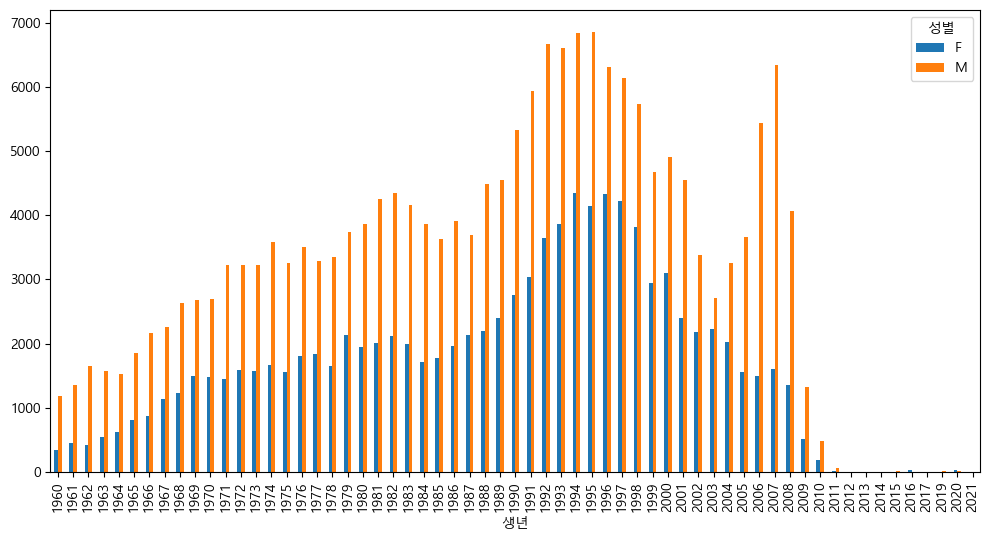

In [46]:
df[['생년', '성별']].value_counts().reset_index().pivot(index = '생년', columns = '성별', values = 'count').plot(kind = 'bar', rot = 90, figsize = (12, 6))

In [70]:
df['이용시간(분)'] = (df['이용시간(초)'] / 60).astype(int) # Int로 변경하는 코드

In [71]:
df['이용시간(분)'].describe()

count    294656.000000
mean         17.574779
std          23.237434
min           0.000000
25%           5.000000
50%           9.000000
75%          19.000000
max         867.000000
Name: 이용시간(분), dtype: float64

<Axes: title={'center': '이용시간분포'}, xlabel='이용시간', ylabel='Frequency'>

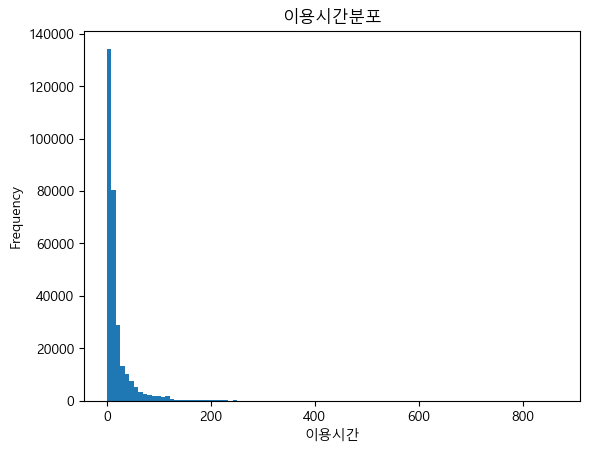

In [75]:
df['이용시간(분)'].plot(kind = 'hist', bins = 100, xlabel = '이용시간', title = '이용시간분포')

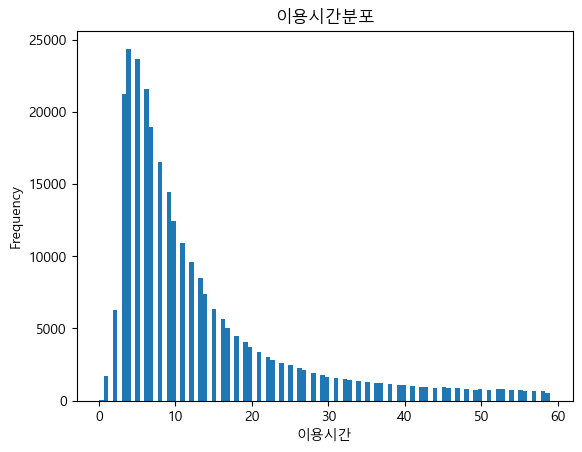

In [65]:
# 위 그래프를 보니, 아웃라이어 800분 이상때문에 분석이 어렵다 > 60분 미만만 추출
df['이용시간(분)'] = df.loc[df['이용시간(분)'] < 60, '이용시간(분)'].plot(kind = 'hist', bins = 100, xlabel = '이용시간', title = '이용시간분포')
# or  df['이용시간(분)'].plot(kind = 'hist', bins = 100, xlabel = '이용시간', title = '이용시간분포', xlim = (0, 60))

<Axes: xlabel='백분위수', ylabel='이용시간(분)'>

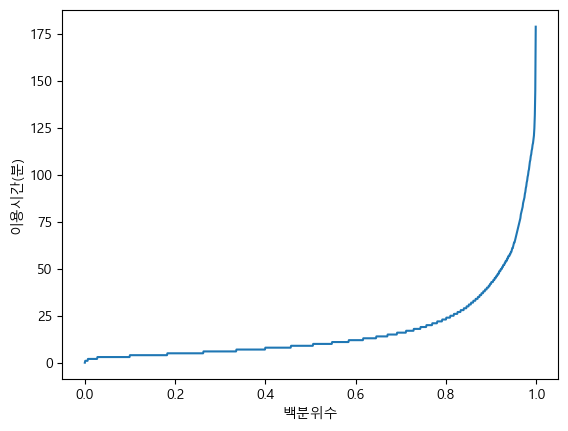

In [76]:
df['이용시간(분)'].quantile(np.arange(0, 1, 0.001)).plot(kind = 'line', ylabel = '이용시간(분)', xlabel = '백분위수')
# Line 그래프가 Default 형식이라서 kind = 'line'을 생략해줘서 동일한 결과
# 이 결과를 해석해보면, 80% 내의 이용자는 25분 이내 자전거 사용하지만, 극소수의 사람들이 100분이상 넘게 타는경우도 있다.

<Axes: xlabel='백분위수', ylabel='이용시간(분)'>

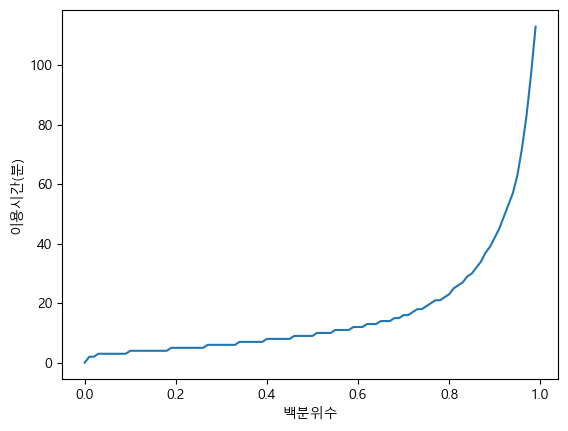

In [109]:
df['이용시간(분)'].quantile(np.arange(0, 1, 0.01)).plot(kind = 'line', ylabel = '이용시간(분)', xlabel = '백분위수')

In [77]:
df.head()

,자전거번호,대여일시,대여 대여소명,반납일시,반납대여소명,이용거리(M),생년,성별,자전거구분,이용시간(초),평균속도(M/S),이용시간(분)
0,SPB-38138,2024-12-01 00:00:13,선유도역 3번출구 앞,2024-12-01 00:02:41,양평동성원아파트,625.10,1997,M,일반자전거,148,4.223649,2
6,SPB-50712,2024-12-01 00:01:27,신트리공원 입구,2024-12-01 00:05:02,신정1동 주민센터 앞,547.61,1998,M,일반자전거,215,2.547023,3
8,SPB-41311,2024-12-01 00:01:31,센트럴파크타워 앞,2024-12-01 00:05:13,용산 파크타워 앞,589.79,1969,M,일반자전거,222,2.656712,3
9,SPB-52417,2024-12-01 00:01:40,천왕이펜하우스3단지 앞,2024-12-01 00:05:27,천왕역 1번 출입구 앞,520.86,1964,M,일반자전거,227,2.294537,3
10,SPB-47696,2024-12-01 00:00:50,양천향교역 7번출구앞,2024-12-01 00:05:29,마곡금호어울림아파트,810.00,2001,M,일반자전거,279,2.903226,4


<Axes: xlabel='대여일시', ylabel='대여#'>

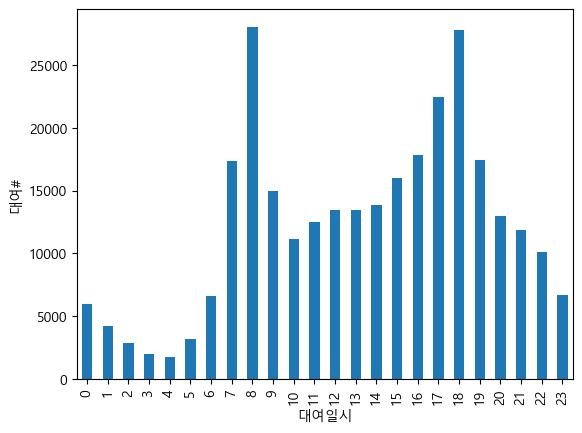

In [110]:
# 대여시각 분포
df['대여일시'].dt.hour.value_counts().sort_index().plot(kind = 'bar', ylabel = '대여#')

<Axes: xlabel='대여일시'>

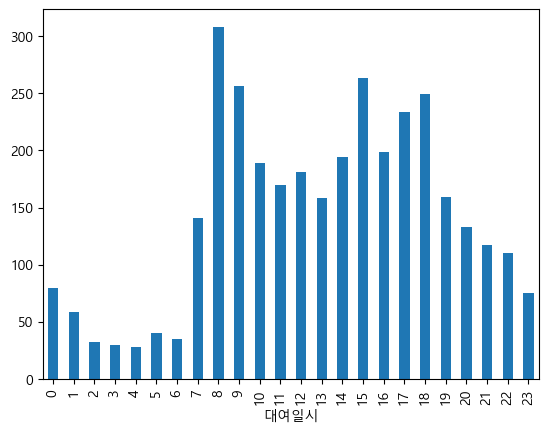

In [88]:
# 새싹 자전거만 확인 > 전체 그림하고 트렌드 상이하다
df.loc[df['자전거구분'] != '일반자전거', '대여일시'].dt.hour.value_counts().sort_index().plot(kind = 'bar')
# loc뒤에 '대여일시'를 넣어주는 이유는 '대여일시'를 기준으로 loc기준으로 추출된 데이터를 정렬하기위해서 새싹 자전거만 확인 > 전체 그림하고 트렌드 상이하다

In [90]:
df['대여 대여소명'].value_counts().iloc[:10].reset_index() # top 10개; 위치를 정확히 알때 iloc[]를 쓴다

,대여 대여소명,count
0,마곡나루역 2번 출구,1520
1,마곡나루역 5번출구 뒤편,1121
2,마곡나루역 3번 출구,1037
3,"발산역 1번, 9번 인근 대여소",802
4,롯데월드타워(잠실역2번출구 쪽),748
5,신정보도육교 아래,720
6,영등포구청역 1번출구,683
7,대륭포스트타워6차 앞,611
8,"양천구청, 보건소 사잇길",588
9,오목교역 3번출구,587


In [91]:
df['반납대여소명'].value_counts().iloc[:10].reset_index()

,반납대여소명,count
0,마곡나루역 2번 출구,1523
1,마곡나루역 5번출구 뒤편,1189
2,마곡나루역 3번 출구,1022
3,롯데월드타워(잠실역2번출구 쪽),806
4,신정보도육교 아래,771
5,"발산역 1번, 9번 인근 대여소",712
6,홍대입구역 2번출구 앞,697
7,영등포구청역 1번출구,697
8,마곡역교차로,666
9,대륭포스트타워6차 앞,640


In [98]:
# 대어와 반납을 묶어서 어떤 Route가 가장 많은지 확인
(df['대여 대여소명'] + '-' + df['반납대여소명']).value_counts()

신정보도육교 아래-오목교역 6번 출구           213
오목교역 6번 출구-신정보도육교 아래           174
LG사이언스파크 E14동-마곡나루역 3번 출구      122
해원리바파크 육교 밑-철도교통관제센터 정문 앞      121
마곡수명산파크3단지 교차로-마곡역교차로          113
                              ... 
평화도봉공원 주변-노원역7번출구                1
종로3가역 2번출구 뒤-당산육갑문               1
창원초등학교 교차로-성원APT버스정류소            1
신용산역 6번출구 앞-동대문역사문화공원역 5번출구      1
아망떼마곡전시장-강서구청사거리(SH타워)           1
Name: count, Length: 99406, dtype: int64

In [103]:
# 비율로도 확인 가능
(df['대여 대여소명'] + '-' + df['반납대여소명']).value_counts(normalize = True) * 100

신정보도육교 아래-오목교역 6번 출구           0.072288
오목교역 6번 출구-신정보도육교 아래           0.059052
LG사이언스파크 E14동-마곡나루역 3번 출구      0.041404
해원리바파크 육교 밑-철도교통관제센터 정문 앞      0.041065
마곡수명산파크3단지 교차로-마곡역교차로          0.038350
                                 ...   
평화도봉공원 주변-노원역7번출구              0.000339
종로3가역 2번출구 뒤-당산육갑문             0.000339
창원초등학교 교차로-성원APT버스정류소          0.000339
신용산역 6번출구 앞-동대문역사문화공원역 5번출구    0.000339
아망떼마곡전시장-강서구청사거리(SH타워)         0.000339
Name: proportion, Length: 99406, dtype: float64

In [ ]:
# 자전거별 이용거리
df.groupby('자전거번호')['이용거리(M)'].sum().sort_values(ascending = False)
df.groupby('자전거번호')['이용거리(M)'].sum().plot(kind = 'hist', bins = 100)